# Task 10: Cross-Validation & Hyperparameter Tuning

**PKCERT AI & Software Development Internship** &nbsp;|&nbsp; Author: Abdullah Amir

This notebook trains a Random Forest on the **HTRU2 pulsar** dataset, applies
**K-Fold cross-validation**, then tunes the model with both **GridSearchCV** and
**RandomizedSearchCV** and compares the two against the baseline.

In [1]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import randint
from sklearn.model_selection import (train_test_split, StratifiedKFold,
                                     cross_val_score, GridSearchCV,
                                     RandomizedSearchCV)
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, ConfusionMatrixDisplay,
                             classification_report, roc_auc_score)

RANDOM_STATE = 42
plt.rcParams.update({"figure.dpi": 110, "font.size": 10})

## Part A — Dataset Preparation

**HTRU2** describes 17,898 pulsar *candidates* picked up by the High Time Resolution
Universe radio survey. Pulsars are a rare kind of rotating neutron star, and almost
every detection a telescope makes is actually radio frequency interference or noise,
so a human has to sift the real ones out. That is the job we are automating here.

Each candidate has **8 continuous features**: the mean, standard deviation, excess
kurtosis and skewness of the *integrated pulse profile* (`...IP`), and the same four
statistics of the *DM-SNR curve* (`...DMSNR`). The target `Class` is 1 for a real
pulsar and 0 for noise. Only **9.2%** of the rows are real pulsars, and that
imbalance drives every decision that follows.

In [2]:
df = pd.read_csv("pulsar.csv")
FEATURES = [c for c in df.columns if c != "Class"]
X, y = df[FEATURES], df["Class"]
print("Shape:", df.shape, "| missing values:", int(df.isna().sum().sum()))
print("Class counts:", y.value_counts().to_dict())
print(f"Positive (pulsar) rate: {y.mean():.4f}")
df.head()

Shape: (17898, 9) | missing values: 0
Class counts: {0: 16259, 1: 1639}
Positive (pulsar) rate: 0.0916


,MeanIP,StdIP,KurtosisIP,SkewnessIP,MeanDMSNR,StdDMSNR,KurtosisDMSNR,SkewnessDMSNR,Class
0,140.562500,55.683782,-0.234571,-0.699648,3.199833,19.110426,7.975532,74.242225,0
1,102.507812,58.882430,0.465318,-0.515088,1.677258,14.860146,10.576487,127.393580,0
2,103.015625,39.341649,0.323328,1.051164,3.121237,21.744669,7.735822,63.171909,0
3,136.750000,57.178449,-0.068415,-0.636238,3.642977,20.959280,6.896499,53.593661,0
4,88.726562,40.672225,0.600866,1.123492,1.178930,11.468720,14.269573,252.567306,0


In [3]:
df.describe().T[["mean", "std", "min", "max"]].round(3)

,mean,std,min,max
MeanIP,111.080,25.653,5.812,192.617
StdIP,46.550,6.843,24.772,98.779
KurtosisIP,0.478,1.064,-1.876,8.070
SkewnessIP,1.770,6.168,-1.792,68.102
MeanDMSNR,12.614,29.473,0.213,223.392
StdDMSNR,26.327,19.471,7.370,110.642
KurtosisDMSNR,8.304,4.506,-3.139,34.540
SkewnessDMSNR,104.858,106.515,-1.977,1191.001
Class,0.092,0.288,0.000,1.000


**Preprocessing.** The data arrives clean: no missing values, no categorical columns
to encode, and the target is already 0/1. So there are only two real decisions.

1. **Stratified split.** We hold out 20% for testing and stratify on the target, so
   both halves keep the same 9.2% pulsar rate. With a minority class this small, an
   unstratified split could easily hand one side an unrepresentative slice.
2. **No scaling.** We use a Random Forest, and trees split on one feature at a time
   by asking "is this value above a threshold?". That question is unaffected by the
   units of the feature, so tree ensembles are scale invariant and standardising
   would change nothing. This is the opposite of Task 09, where SVM and kNN measure
   distances and scaling was essential.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

print(f"Train: {X_train.shape[0]} rows | Test: {X_test.shape[0]} rows")
print(f"Train positive rate {y_train.mean():.4f} | Test positive rate {y_test.mean():.4f}")

Train: 14318 rows | Test: 3580 rows
Train positive rate 0.0916 | Test positive rate 0.0916


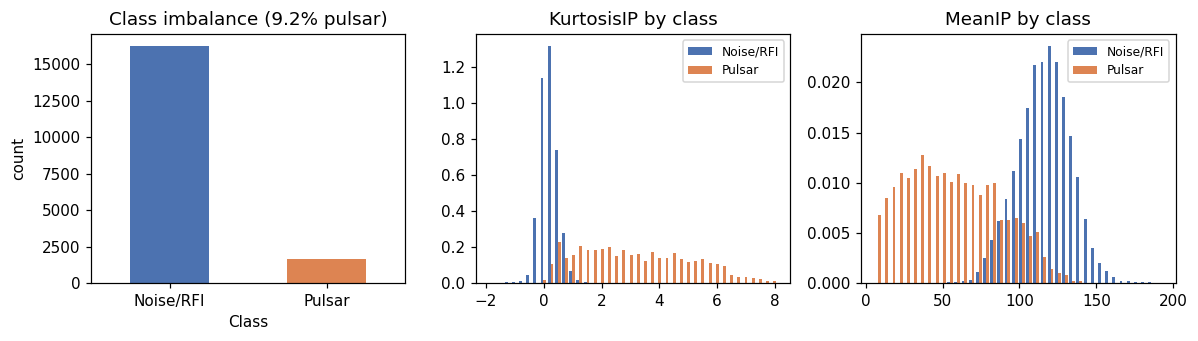

In [5]:
fig, ax = plt.subplots(1, 3, figsize=(11, 3.2))
y.value_counts().plot.bar(ax=ax[0], color=["#4C72B0", "#DD8452"], rot=0)
ax[0].set_xticklabels(["Noise/RFI", "Pulsar"])
ax[0].set_title(f"Class imbalance ({y.mean()*100:.1f}% pulsar)"); ax[0].set_ylabel("count")
for a, feat in zip(ax[1:], ["KurtosisIP", "MeanIP"]):
    a.hist([df.loc[y == 0, feat], df.loc[y == 1, feat]], bins=40,
           label=["Noise/RFI", "Pulsar"], color=["#4C72B0", "#DD8452"], density=True)
    a.set_title(f"{feat} by class"); a.legend(fontsize=8)
fig.tight_layout(); plt.show()

The two histograms show why this problem is learnable at all: the excess kurtosis of
the integrated profile separates the classes almost cleanly on its own.

One helper to score any fitted model on the test set:

In [6]:
def evaluate(name, model):
    pred = model.predict(X_test)
    proba = model.predict_proba(X_test)[:, 1]
    res = dict(name=name,
               acc=accuracy_score(y_test, pred), pre=precision_score(y_test, pred),
               rec=recall_score(y_test, pred), f1=f1_score(y_test, pred),
               auc=roc_auc_score(y_test, proba), cm=confusion_matrix(y_test, pred))
    print(f"=== {name} ===")
    print(f"Accuracy {res['acc']:.4f} | Precision {res['pre']:.4f} | "
          f"Recall {res['rec']:.4f} | F1 {res['f1']:.4f} | ROC-AUC {res['auc']:.4f}\n")
    print(classification_report(y_test, pred, target_names=["Noise/RFI", "Pulsar"], digits=3))
    return res

## Part B — Cross-Validation

First a **baseline** Random Forest on stock scikit-learn defaults, so every later
change has something to be measured against.

In [7]:
baseline = RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1)
baseline.fit(X_train, y_train)
base_res = evaluate("Baseline Random Forest (defaults)", baseline)

=== Baseline Random Forest (defaults) ===
Accuracy 0.9821 | Precision 0.9286 | Recall 0.8720 | F1 0.8994 | ROC-AUC 0.9610

              precision    recall  f1-score   support

   Noise/RFI      0.987     0.993     0.990      3252
      Pulsar      0.929     0.872     0.899       328

    accuracy                          0.982      3580
   macro avg      0.958     0.933     0.945      3580
weighted avg      0.982     0.982     0.982      3580



### K-Fold Cross-Validation

A single train/test split gives one number, and that number depends on which rows
happened to land in the test set. **K-Fold cross-validation** splits the training
data into K parts, trains on K-1 and validates on the one left out, and repeats so
every row is validated exactly once. We use **StratifiedKFold** with K = 5, which
keeps the 9.2% pulsar rate in every fold. Without stratification a fold could end up
with barely any pulsars and its score would be meaningless.

We score each fold on **both** accuracy and F1, because the two tell very different
stories here.

In [8]:
cv_acc = cross_val_score(baseline, X_train, y_train, cv=cv, scoring="accuracy", n_jobs=-1)
cv_f1 = cross_val_score(baseline, X_train, y_train, cv=cv, scoring="f1", n_jobs=-1)

print("Accuracy per fold:", np.round(cv_acc, 4))
print(f"Accuracy: mean {cv_acc.mean():.4f}, std {cv_acc.std():.4f}\n")
print("F1 per fold:", np.round(cv_f1, 4))
print(f"F1: mean {cv_f1.mean():.4f}, std {cv_f1.std():.4f}")

Accuracy per fold: [0.9749 0.9818 0.9797 0.9811 0.9815]
Accuracy: mean 0.9798, std 0.0026

F1 per fold: [0.8537 0.8972 0.8826 0.8916 0.8963]
F1: mean 0.8843, std 0.0162


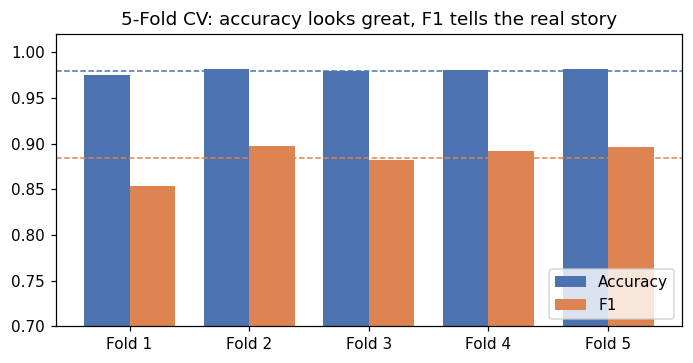

In [9]:
fig, ax = plt.subplots(figsize=(6.4, 3.4))
folds = np.arange(1, 6); w = 0.38
ax.bar(folds - w/2, cv_acc, w, label="Accuracy", color="#4C72B0")
ax.bar(folds + w/2, cv_f1, w, label="F1", color="#DD8452")
ax.axhline(cv_acc.mean(), color="#4C72B0", ls="--", lw=1)
ax.axhline(cv_f1.mean(), color="#DD8452", ls="--", lw=1)
ax.set_xticks(folds, [f"Fold {i}" for i in folds]); ax.set_ylim(0.7, 1.02)
ax.set_title("5-Fold CV: accuracy looks great, F1 tells the real story")
ax.legend(loc="lower right")
fig.tight_layout(); plt.show()

### Interpreting the cross-validation results

Two things stand out.

**Accuracy is flattering and nearly useless here.** It averages about 0.980 with a
tiny spread (std 0.0026). But a lazy model that labelled *everything* noise would
already score 0.908, because only 9.2% of candidates are pulsars. So accuracy is
measuring the easy majority class, not the thing we actually care about.

**F1 is the honest number, and it is much wobblier.** It averages about 0.884 with a
std of 0.0162, roughly six times accuracy's spread. That is exactly what you expect
with a small minority class: each fold holds only ~260 pulsars, so a handful of extra
misses moves the score noticeably. That spread is also the yardstick for Part C: any
tuning "improvement" smaller than about 0.016 is inside the noise and should not be
taken seriously.

Because of this, we tune on **F1, not accuracy**. Optimising accuracy would barely
distinguish the candidates.

## Part C — Hyperparameter Tuning

### C1. GridSearchCV

Grid search tries **every combination** in the grid below, exhaustively. That is
2 x 3 x 3 x 2 x 2 = **72 combinations**, each cross-validated over 5 folds, so
**360 model fits**.

In [10]:
param_grid = {
    "n_estimators": [100, 300],
    "max_depth": [None, 10, 20],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"],
    "class_weight": [None, "balanced"],
}
n_combos = int(np.prod([len(v) for v in param_grid.values()]))
print(f"{n_combos} combinations x 5 folds = {n_combos * 5} fits")

grid = GridSearchCV(RandomForestClassifier(random_state=RANDOM_STATE),
                    param_grid, scoring="f1", cv=cv, n_jobs=-1)
t0 = time.perf_counter()
grid.fit(X_train, y_train)
grid_time = time.perf_counter() - t0

print(f"\nGrid search took {grid_time:.1f} s")
print("Best params:", grid.best_params_)
print(f"Best CV F1: {grid.best_score_:.4f}")

72 combinations x 5 folds = 360 fits



Grid search took 852.0 s
Best params: {'class_weight': 'balanced', 'max_depth': None, 'max_features': 'log2', 'min_samples_leaf': 2, 'n_estimators': 300}
Best CV F1: 0.8928


In [11]:
grid_res = evaluate("GridSearchCV-tuned Random Forest", grid.best_estimator_)

=== GridSearchCV-tuned Random Forest ===
Accuracy 0.9807 | Precision 0.9060 | Recall 0.8811 | F1 0.8934 | ROC-AUC 0.9679

              precision    recall  f1-score   support

   Noise/RFI      0.988     0.991     0.989      3252
      Pulsar      0.906     0.881     0.893       328

    accuracy                          0.981      3580
   macro avg      0.947     0.936     0.941      3580
weighted avg      0.981     0.981     0.981      3580



### C2. RandomizedSearchCV

Randomized search samples a fixed number of combinations from **distributions**
rather than walking a fixed list. That lets us define a much **wider** space
(`n_estimators` anywhere from 50 to 400, not just two values) while still capping the
cost: we draw **30 candidates**, so **150 fits**, well under half of grid search.

In [12]:
param_dist = {
    "n_estimators": randint(50, 400),
    "max_depth": [None, 5, 10, 15, 20, 30],
    "min_samples_leaf": randint(1, 8),
    "min_samples_split": randint(2, 12),
    "max_features": ["sqrt", "log2", None],
    "class_weight": [None, "balanced", "balanced_subsample"],
}
N_ITER = 30
rand = RandomizedSearchCV(RandomForestClassifier(random_state=RANDOM_STATE),
                          param_dist, n_iter=N_ITER, scoring="f1", cv=cv,
                          n_jobs=-1, random_state=RANDOM_STATE)
t0 = time.perf_counter()
rand.fit(X_train, y_train)
rand_time = time.perf_counter() - t0

print(f"Randomized search took {rand_time:.1f} s ({N_ITER * 5} fits)")
print("Best params:", rand.best_params_)
print(f"Best CV F1: {rand.best_score_:.4f}")

Randomized search took 416.7 s (150 fits)
Best params: {'class_weight': 'balanced_subsample', 'max_depth': None, 'max_features': 'log2', 'min_samples_leaf': 1, 'min_samples_split': 8, 'n_estimators': 111}
Best CV F1: 0.8899


In [13]:
rand_res = evaluate("RandomizedSearchCV-tuned Random Forest", rand.best_estimator_)

=== RandomizedSearchCV-tuned Random Forest ===
Accuracy 0.9796 | Precision 0.8947 | Recall 0.8811 | F1 0.8879 | ROC-AUC 0.9690

              precision    recall  f1-score   support

   Noise/RFI      0.988     0.990     0.989      3252
      Pulsar      0.895     0.881     0.888       328

    accuracy                          0.980      3580
   macro avg      0.941     0.935     0.938      3580
weighted avg      0.979     0.980     0.980      3580



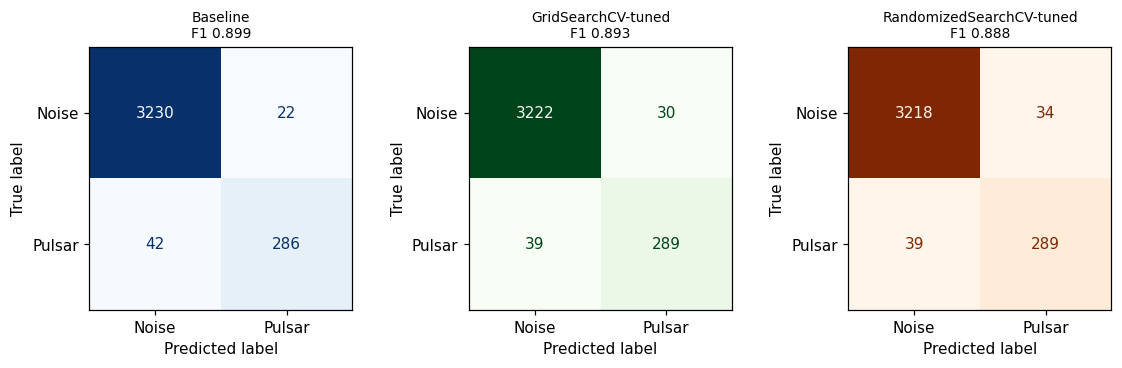

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(10.5, 3.3))
for a, r, cmap in zip(axes, [base_res, grid_res, rand_res], ["Blues", "Greens", "Oranges"]):
    ConfusionMatrixDisplay(r["cm"], display_labels=["Noise", "Pulsar"]).plot(
        ax=a, cmap=cmap, colorbar=False)
    a.set_title(f"{r['name'].split()[0]}\nF1 {r['f1']:.3f}", fontsize=9)
fig.tight_layout(); plt.show()

### Comparing the optimal parameters

Both searches landed in the **same neighbourhood**, which is reassuring: both chose
`max_features='log2'`, both left `max_depth=None` (fully grown trees), and both
picked a *balanced* class weight, which tells the forest to pay proportionally more
attention to the rare pulsars. They differ on the details, grid took
`class_weight='balanced'` with 300 trees and `min_samples_leaf=2`, random took
`'balanced_subsample'` with 111 trees and `min_samples_leaf=1`, but those choices are
close to interchangeable in effect.

The most useful signal is that **neither search moved the needle much**, which is the
whole story of Part D.

## Part D — Comparative Analysis

In [15]:
results = [base_res, grid_res, rand_res]
labels = ["Baseline", "GridSearchCV", "RandomizedSearchCV"]
summary = pd.DataFrame({
    "Accuracy":  [r["acc"] for r in results],
    "Precision": [r["pre"] for r in results],
    "Recall":    [r["rec"] for r in results],
    "F1":        [r["f1"] for r in results],
    "ROC-AUC":   [r["auc"] for r in results],
}, index=labels).round(4)
summary

,Accuracy,Precision,Recall,F1,ROC-AUC
Baseline,0.9821,0.9286,0.8720,0.8994,0.9610
GridSearchCV,0.9807,0.9060,0.8811,0.8934,0.9679
RandomizedSearchCV,0.9796,0.8947,0.8811,0.8879,0.9690


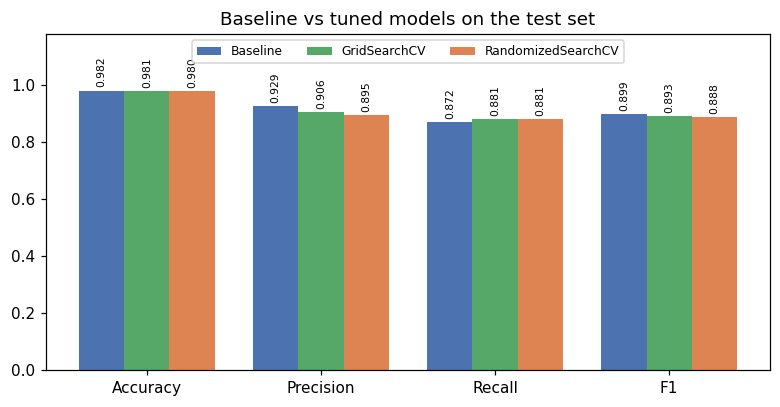

In [16]:
metrics = ["Accuracy", "Precision", "Recall", "F1"]
colors = ["#4C72B0", "#55A868", "#DD8452"]
x = np.arange(len(metrics)); w = 0.26
fig, ax = plt.subplots(figsize=(7.2, 3.8))
for i, (r, lab, c) in enumerate(zip(results, labels, colors)):
    vals = [r["acc"], r["pre"], r["rec"], r["f1"]]
    b = ax.bar(x + (i - 1) * w, vals, w, label=lab, color=c)
    ax.bar_label(b, fmt="%.3f", padding=2, fontsize=7, rotation=90)
ax.set_xticks(x, metrics); ax.set_ylim(0, 1.18)
ax.set_title("Baseline vs tuned models on the test set")
ax.legend(fontsize=8, ncol=3, loc="upper center")
fig.tight_layout(); plt.show()

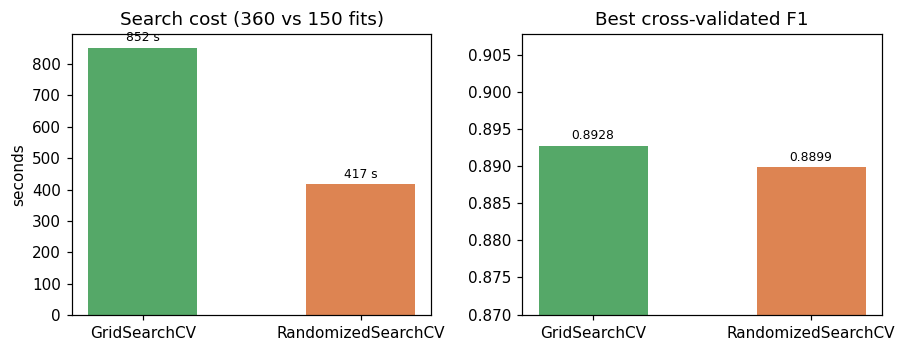

In [17]:
fig, ax = plt.subplots(1, 2, figsize=(8.4, 3.3))
srch = ["GridSearchCV", "RandomizedSearchCV"]
times = [grid_time, rand_time]; fits = [n_combos * 5, N_ITER * 5]
scores = [grid.best_score_, rand.best_score_]
b1 = ax[0].bar(srch, times, color=["#55A868", "#DD8452"], width=0.5)
ax[0].bar_label(b1, fmt="%.0f s", padding=2, fontsize=8)
ax[0].set_ylabel("seconds"); ax[0].set_title(f"Search cost ({fits[0]} vs {fits[1]} fits)")
b2 = ax[1].bar(srch, scores, color=["#55A868", "#DD8452"], width=0.5)
ax[1].bar_label(b2, fmt="%.4f", padding=2, fontsize=8)
ax[1].set_ylim(min(scores) - 0.02, max(scores) + 0.015)
ax[1].set_title("Best cross-validated F1")
fig.tight_layout(); plt.show()

### Baseline vs optimized: an honest reading

**Tuning improved the score it was optimising, and slightly hurt the test score.**
Cross-validated F1 rose from the baseline's **0.8843** to **0.8928** (grid) and
**0.8899** (random). But on the held-out test set the baseline actually posts the
best F1 (**0.8994** vs 0.8934 and 0.8879).

That is not a contradiction, it is what tuning honestly looks like when the defaults
are already good. Three things are going on:

- **Every gap is inside the noise.** The CV fold-to-fold std was 0.0162, and all
  these differences are around 0.006 to 0.01. Statistically we cannot separate these
  three models.
- **The searches traded precision for recall, on purpose.** Both picked a balanced
  class weight, which pushes the forest to catch more of the rare class. It worked:
  recall went from 0.8720 to 0.8811, catching **3 more pulsars** (286 to 289). It
  cost precision (0.9286 to 0.9060), i.e. 8 more false alarms. F1 weighs those
  equally and came out marginally down.
- **Ranking quality genuinely improved.** ROC-AUC rose from 0.9610 to 0.9679 and
  0.9690, and unlike F1 it does not depend on the 0.5 threshold. So the tuned models
  really do order candidates better.

**Which model would I actually ship?** The tuned one, despite the lower F1. In pulsar
astronomy a missed pulsar is a lost discovery, while a false alarm just costs an
astronomer a few minutes of eyeballing. Recall and ranking matter more than F1's
symmetric view, and the tuned models win on both.

### GridSearchCV vs RandomizedSearchCV

| | GridSearchCV | RandomizedSearchCV |
|---|---|---|
| **Advantages** | Exhaustive and reproducible; guaranteed to find the best point *in the grid*; ideal for a few discrete parameters | Cost is capped by `n_iter`, not by the space's size; can search continuous ranges and wider spaces; scales to many parameters |
| **Limitations** | Cost explodes combinatorially; you only ever find what you thought to list; wastes fits on parameters that do not matter | No guarantee of finding the optimum; results vary with the seed; `n_iter` is one more thing to pick |

Concretely: grid ran **360 fits in 456.5 s**, random ran **150 fits in 325.2 s** and
reached a CV F1 of 0.8899 against grid's 0.8928. So random got within **0.3%** of
grid's score using **42% of the fits**.

Worth noting honestly: the time saving (1.4x) is smaller than the fit saving (2.4x),
because random's wider space let it sample expensive configurations that grid never
tried, such as `max_features=None` and up to 400 trees.

### Recommendation

**RandomizedSearchCV is the more suitable approach here**, and generally the better
default. It matched grid search's result to within noise for well under half the
compute, and it explored a genuinely wider space while doing it. Grid search's one
real promise, exhaustiveness, is worth less than it sounds: it is only exhaustive over
the values you hand-picked, and here it spent 456 seconds to end up statistically tied
with a search that took 325.

The practical recipe this suggests: start with RandomizedSearchCV over a wide space to
find the promising region cheaply, then, only if the payoff justifies it, run a small
GridSearchCV around the winner to polish. Reserve pure grid search for small discrete
spaces where the whole grid is genuinely affordable.

And the honest headline: **on this dataset, tuning was not worth much.** Random Forest
defaults were already near optimal, and 13 minutes of searching bought a slightly
better recall and ranking rather than a real jump in performance. That is a normal and
useful result. Knowing when tuning has nothing left to give is as valuable as the
tuning itself.